In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

### Electron density

Coefficients:
a0 = -0.023107428755594198
a1 = -0.039465357253247624
a2 = 0.18684160985768736
a3 = -0.46053464274675215
a4 = -0.6637341811020937


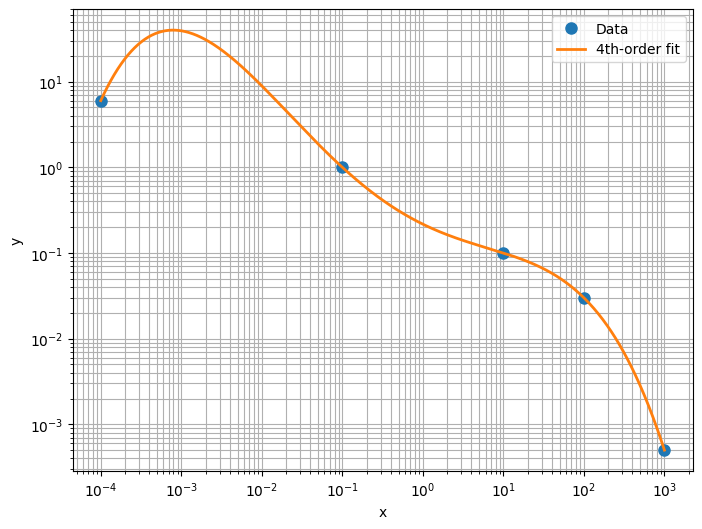

In [2]:
#for ne
x = np.array([1e-4, 1e-1, 1e1, 1e2, 1e3])#kpc
y = np.array([6, 1, 0.1, 3e-2, 5e-4])

# Log-transform
logx = np.log10(x)
logy = np.log10(y)

# 4th-order polynomial fit
coeffs = np.polyfit(logx, logy, 4)

print("Coefficients:")
for i, c in enumerate(coeffs):
    print(f"a{i} = {c}")

# Smooth curve
xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)

logyfit = np.polyval(coeffs, np.log10(xfit))
yfit = 10**logyfit

# Plot
plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=8, label='Data')
plt.loglog(xfit, yfit, lw=2, label='4th-order fit')

plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, which='both')
plt.legend()
plt.show()

#NOOO ,its overshooting ! 


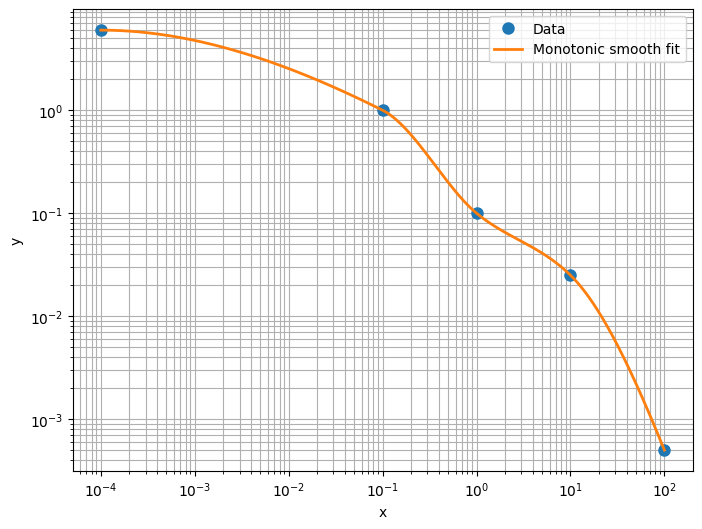

In [3]:
#Electron density in galaxy (milky way), from Yao, Manchester, Wang , https://arxiv.org/pdf/1610.09448
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

x = np.array([1e-4, 1e-1, 1, 1e1, 1e2])#kpc
y = np.array([6, 1, 0.1, 2.5e-2, 5e-4])

# interpolate in log-log space
logx = np.log10(x)
logy = np.log10(y)

interp = PchipInterpolator(logx, logy)
#PCHIP stands for Piecewise Cubic Hermite Interpolating Polynomial.

xfit = np.logspace(logx.min(), logx.max(), 2000)
yfit = 10**interp(np.log10(xfit))
plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=8, label='Data')
plt.loglog(xfit, yfit, lw=2, label='Monotonic smooth fit')

plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, which='both')
plt.legend()
plt.show()

### Magnetic Field 

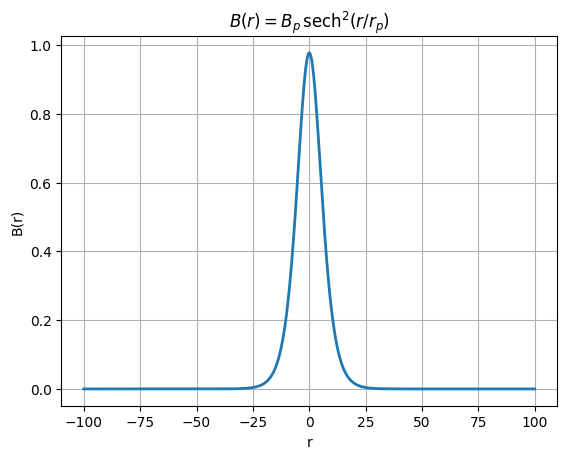

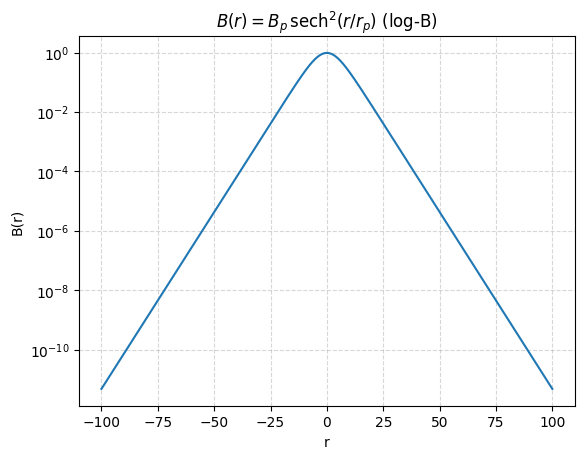

In [4]:
#For the B_parallel, from https://arxiv.org/pdf/2311.12120
#sech2 plot 

# ---- fill these ----
Bp = 0.978 #+-0.033 #muG   # peak magnetic field
rp = 7.29  #+- 0.06 #kpc  # scale radius
# --------------------

r = np.linspace(-100, 100, 1000) #kpc

B = Bp * (1 / np.cosh(r / rp))**2   # sech^2(x) = 1/cosh^2(x)

plt.plot(r, B, lw=2)
plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$")
plt.grid(True)
plt.show()



#loglog
plt.semilogy(r, B)

plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$ (log-B)")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

## Faraday Rotation 

Impact parameter b = 0.0 kpc
RM = 0.6201 rad/m^2
Δa = 19.1393 rad
Δa = 1096.60 deg


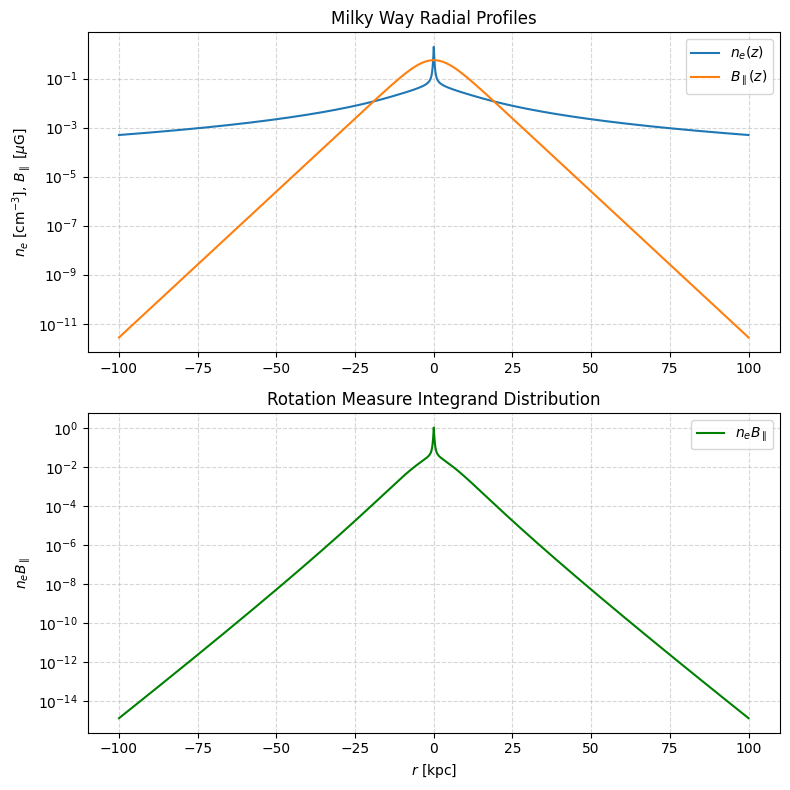

In [38]:
b = 0.0   # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc


# LOS component
def B_parallel(r):
    return (Bp / np.cosh(r / rp)**2) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B
RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle (fixed frequency)
nu = 54e6
c = 3e8
lambda_sq = (c / nu)**2

FR_0 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")
print(f"Δa = {FR_0:.4f} rad")
print(f"Δa = {np.degrees(FR_0):.2f} deg")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.semilogy(z, ne, label=r'$n_e(z)$')
ax1.semilogy(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.semilogy(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

## RM v/s Lambda_sq

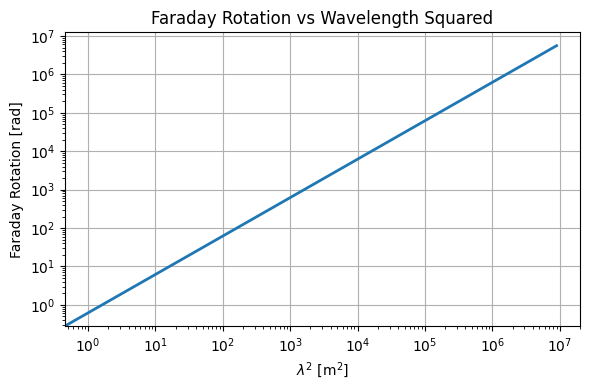

In [111]:
b = 0.0   # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc


# LOS component
def B_parallel(r):
    return (Bp / np.cosh(r / rp)**2) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B
RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle with varying freq
lambda_sq = np.linspace(0, 9e6,9000000) # 100 khz = 3000 m 
FR_0 = lambda_sq * RM   #Psi_0 term value unknown 

plt.figure(figsize=(6,4))
plt.loglog(lambda_sq, FR_0, lw=2)
plt.xlabel(r'$\lambda^2\ \mathrm{[m^2]}$')
plt.ylabel('Faraday Rotation [rad]')
plt.title('Faraday Rotation vs Wavelength Squared')
plt.grid(True)
plt.tight_layout()
plt.show()

Impact parameter b = 1 kpc
RM = 0.3261 rad/m^2
Δa = 10.0635 rad
Δa = 576.60 deg


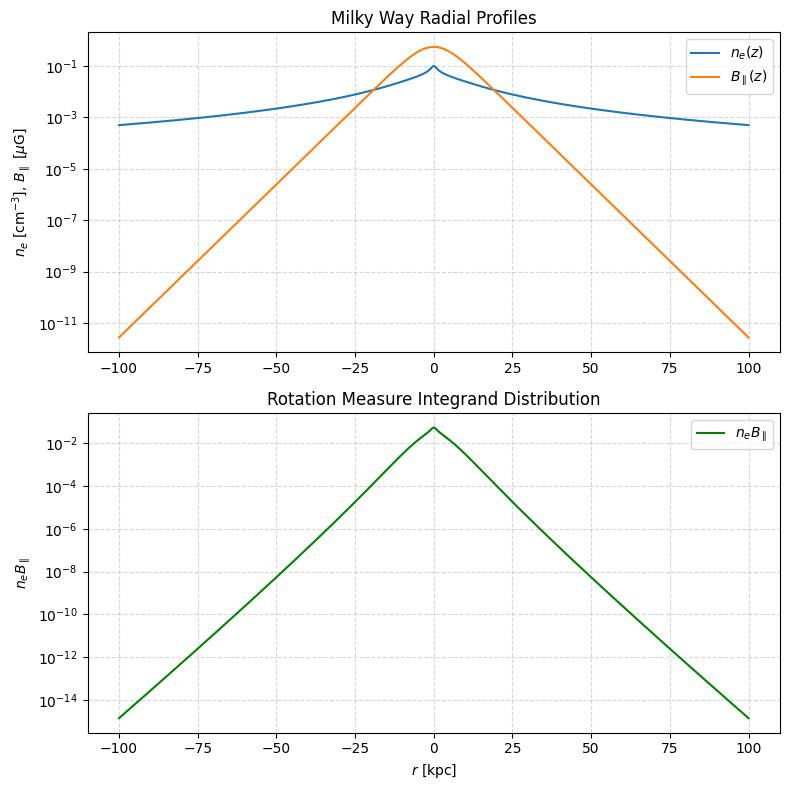

In [40]:
b = 1  # kpc
  # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc

def B_field(r):
    return Bp / np.cosh(r / rp)**2

# LOS component
def B_parallel(r):
    return B_field(r) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B

RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle (fixed frequency)
nu = 54e6
c = 3e8
lambda_sq = (c / nu)**2

FR_1 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")
print(f"Δa = {FR_1:.4f} rad")
print(f"Δa = {np.degrees(FR_1):.2f} deg")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.semilogy(z, ne, label=r'$n_e(z)$')
ax1.semilogy(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.semilogy(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

Impact parameter b = 7.29 kpc
RM = 0.0839 rad/m^2
Δa = 2.5908 rad
Δa = 148.44 deg


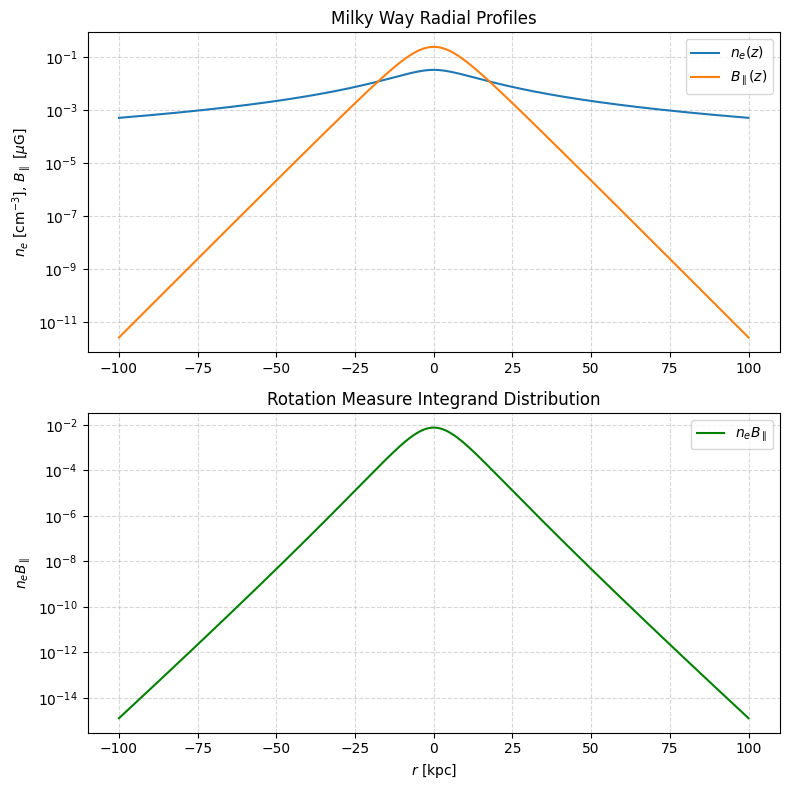

In [42]:
b = 7.29  # kpc
  # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc

def B_field(r):
    return Bp / np.cosh(r / rp)**2

# LOS component
def B_parallel(r):
    return B_field(r) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B

RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle (fixed frequency)
nu = 54e6
c = 3e8
lambda_sq = (c / nu)**2

FR_2 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")
print(f"Δa = {FR_2:.4f} rad")
print(f"Δa = {np.degrees(FR_2):.2f} deg")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.semilogy(z, ne, label=r'$n_e(z)$')
ax1.semilogy(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.semilogy(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

Impact parameter b = 10 kpc
RM = 0.0390 rad/m^2
Δa = 1.2036 rad
Δa = 68.96 deg


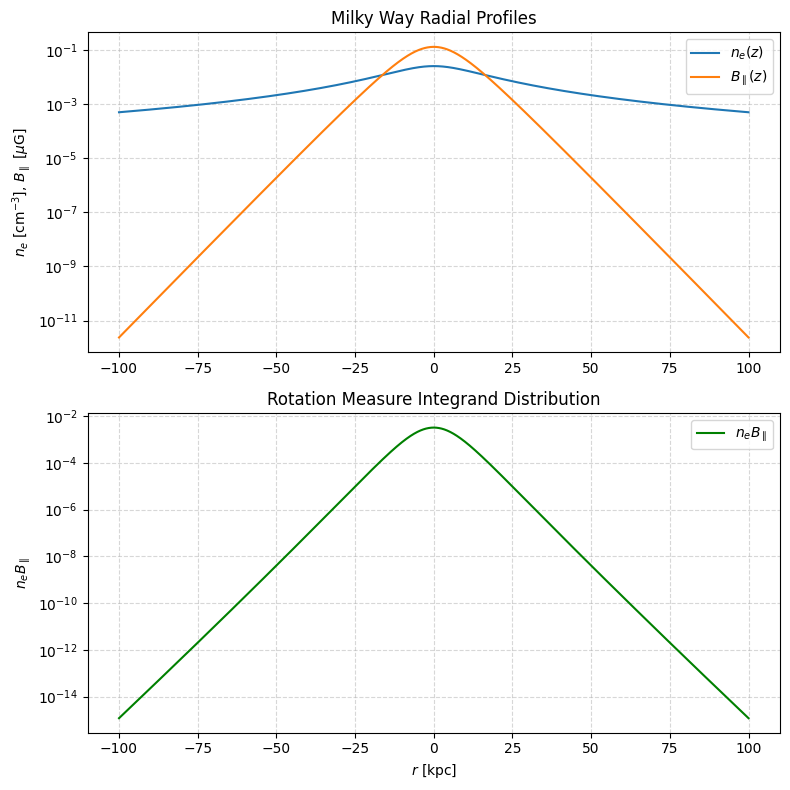

In [44]:
b = 10  # kpc
  # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc

def B_field(r):
    return Bp / np.cosh(r / rp)**2

# LOS component
def B_parallel(r):
    return B_field(r) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B

RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle (fixed frequency)
nu = 54e6
c = 3e8
lambda_sq = (c / nu)**2

FR_3 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")
print(f"Δa = {FR_3:.4f} rad")
print(f"Δa = {np.degrees(FR_3):.2f} deg")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.semilogy(z, ne, label=r'$n_e(z)$')
ax1.semilogy(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.semilogy(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

Impact parameter b = 100 kpc
RM = 0.000000 rad/m^2
Δa = 0.0000 rad
Δa = 0.00 deg


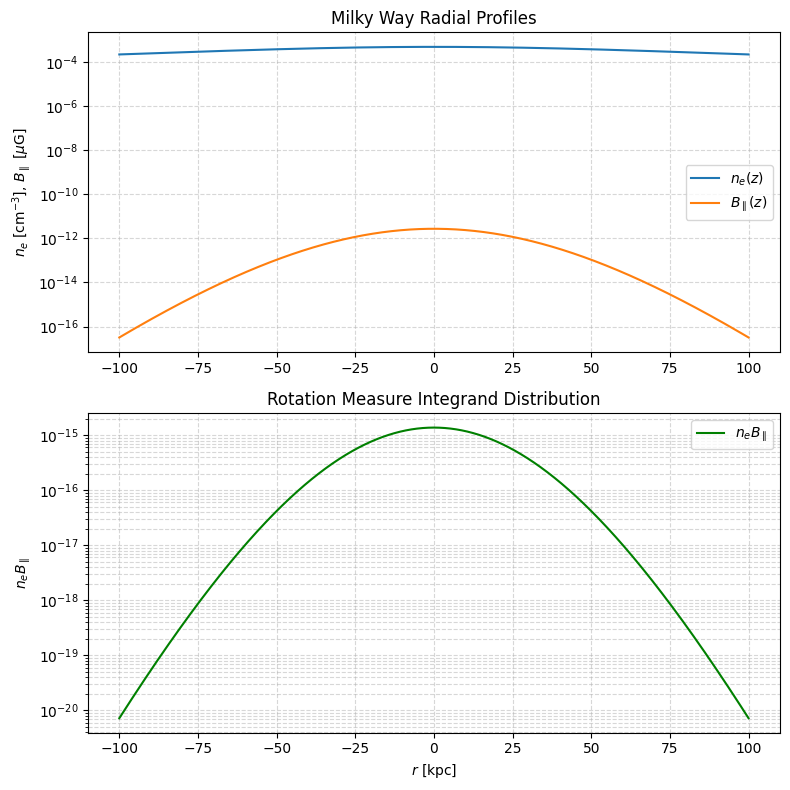

In [48]:
b = 100  # kpc
  # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc

def B_field(r):
    return Bp / np.cosh(r / rp)**2

# LOS component
def B_parallel(r):
    return B_field(r) / np.sqrt(3)

#LOS 

L_max = 100  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  = B_parallel(r)                  # microGauss

integrand = ne * B

RM = 0.812 * trapezoid(integrand, z)

# Faraday rotation angle (fixed frequency)
nu = 54e6
c = 3e8
lambda_sq = (c / nu)**2

FR_4 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.6f} rad/m^2")
print(f"Δa = {FR_4:.4f} rad")
print(f"Δa = {np.degrees(FR_4):.2f} deg")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.semilogy(z, ne, label=r'$n_e(z)$')
ax1.semilogy(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.semilogy(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

-----------------------------------------------------------
   b (kpc) |           RM |     Δa (rad) |     Δa (deg)
-----------------------------------------------------------
      0.00 |     0.620111 |    19.139238 |      1096.60
      1.00 |     0.326059 |    10.063542 |       576.60
      7.29 |     0.083943 |     2.590839 |       148.44
     10.00 |     0.038997 |     1.203625 |        68.96
    100.00 |     0.000000 |     0.000000 |         0.00
-----------------------------------------------------------


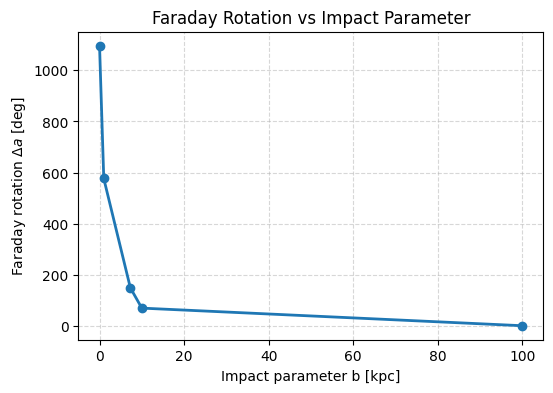

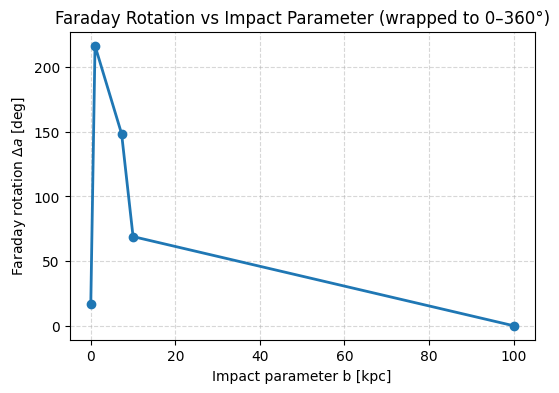

In [104]:
# creating a plot of b (0,1,7.29,10,100   kpc) vs all FR_n ( n = 0,1,2,3,4)
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

# -------------------------
# Electron density model
# -------------------------
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)

def ne(r):
    return 10**ne_interp(np.log10(r))

# -------------------------
# Magnetic field model
# -------------------------
Bp = 0.978   # microGauss
rp = 7.29    # kpc

def B_field(r):
    return Bp / np.cosh(r / rp)**2

def B_parallel(r):
    return B_field(r) / np.sqrt(3)

# -------------------------
# LOS integrator
# -------------------------
def compute_FR(b, L_max=100, N_z=5000):
    z = np.linspace(-L_max, L_max, N_z)
    r = np.sqrt(b**2 + z**2)
    r = np.maximum(r, 1e-6)

    ne_vals = ne(r)
    B_vals  = B_parallel(r)

    integrand = ne_vals * B_vals

    RM = 0.812 * trapezoid(integrand, z)

    nu = 54e6
    c = 3e8
    lambda_sq = (c / nu)**2

    FR = lambda_sq * RM
    return RM, FR

#array of b  
b_list = np.array([0.0001, 1, 7.29, 10, 100])  # kpc

RM_list = []
FR_list = []

for b in b_list:
    RM, FR = compute_FR(b)
    RM_list.append(RM)
    FR_list.append(FR)

RM_list = np.array(RM_list)
FR_list = np.array(FR_list)

# -------------------------
# Print results
# -------------------------
FR_deg_list = np.degrees(FR_list)

print("-----------------------------------------------------------")
print(f"{'b (kpc)':>10} | {'RM':>12} | {'Δa (rad)':>12} | {'Δa (deg)':>12}")
print("-----------------------------------------------------------")

for b, rm, fr_rad, fr_deg in zip(b_list, RM_list, FR_list, FR_deg_list):
    print(f"{b:10.2f} | {rm:12.6f} | {fr_rad:12.6f} | {fr_deg:12.2f}")

print("-----------------------------------------------------------")
# -------------------------
# Plot FR vs b
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(b_list, FR_deg_list, marker='o', lw=2)
#plt.xscale('log')
plt.xlabel('Impact parameter b [kpc]')
plt.ylabel(r'Faraday rotation $\Delta a$ [deg]')
plt.title('Faraday Rotation vs Impact Parameter')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

FR_deg_wrapped = FR_deg_list % 360
plt.figure(figsize=(6,4))
plt.plot(b_list, FR_deg_wrapped, marker='o', lw=2)
plt.xlabel('Impact parameter b [kpc]')
plt.ylabel(r'Faraday rotation $\Delta a$ [deg]')
plt.title('Faraday Rotation vs Impact Parameter (wrapped to 0–360°)')

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

## NFW Profile

IN THE OTHER NOTEBOOK !!!!!!!

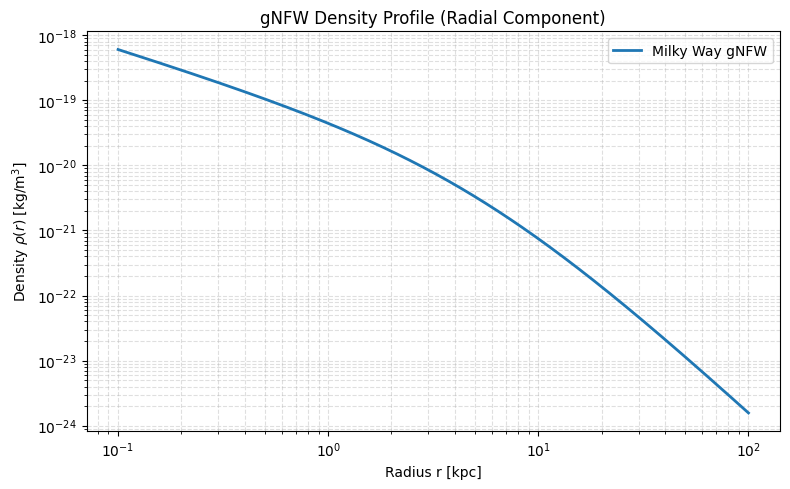

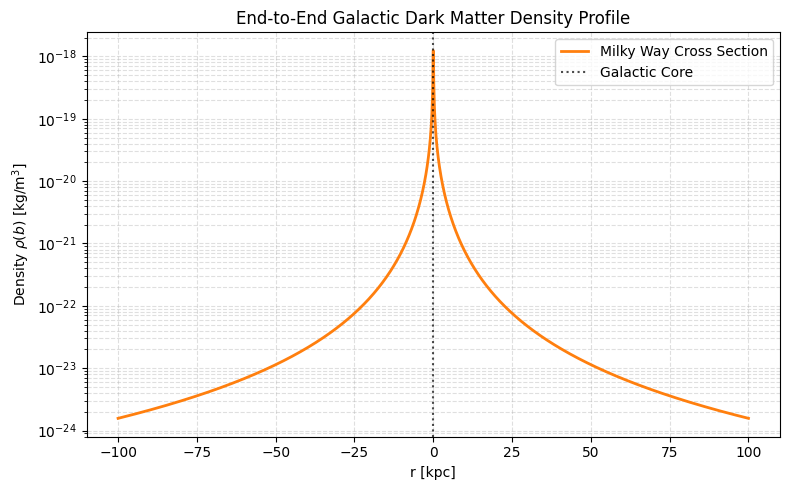

In [103]:
#resulting density is in in kg/kpc3
import numpy as np
import matplotlib.pyplot as plt

Msun = 2e30  # kg 
params1 = {'M_0': 3.21 * 1e11, 'r_s': 5.26}  

M_0 = 3.21 * 1e11
r_s = 5.26 

kpc = 3.086e19  # m
r_s_m = r_s * kpc

rho_0 = (M_0 * Msun) / (4 * np.pi * r_s_m**3)

#  gNFW Profile
def gnfw(r, M_0, r_s):
    
    # Prevents dividing by zero at the absolute center
    x = r / r_s
    return  rho_0 / (x * (1 + x)**2)

# end-to-end 
def full_gnfw(r, M_0, r_s):
  
    r_magnitude = np.abs(r)
    return gnfw(r_magnitude, M_0, r_s)

r_log = np.logspace(-1, 2, 2000)             # For the log-log profile (0.1 to 100 kpc)
r_linear = np.linspace(-100.0, 100.0, 2000)   # Continuous End-to-End Galaxy diameter axis


rho_log = gnfw(r_log, **params1)
rho_linear = full_gnfw(r_linear, **params1)

# PLOT 1: Standard Radial Profile (Log-Log)
plt.figure(figsize=(8, 5))
plt.loglog(r_log, rho_log, linewidth=2, color='tab:blue', label='Milky Way gNFW')
plt.xlabel('Radius r [kpc]')
plt.ylabel(r'Density $\rho(r)$ [kg/m$^3$]')
plt.title('gNFW Density Profile (Radial Component)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 2: End-to-End Cross Section Profile (-100 to +100 kpc)
plt.figure(figsize=(8, 5))

plt.semilogy(r_linear, rho_linear, linewidth=2, color='tab:orange', label='Milky Way Cross Section')
plt.xlabel('r [kpc]')
plt.ylabel(r'Density $\rho(b)$ [kg/m$^3$]')
plt.title('End-to-End Galactic Dark Matter Density Profile')
plt.axvline(0, color='black', linestyle=':', alpha=0.7, label='Galactic Core')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

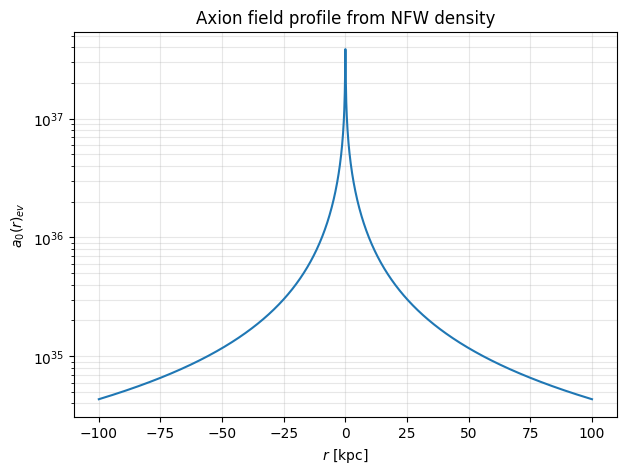

In [96]:
Rs_kpc = 5.26 # same as r_s 
Rs = Rs_kpc * 1.5 *1e41 *1e-9 #ev^-1     #to convert for natural units 

#Mass 
m_a = 1e-27#eV

rho_SI_to_natural = 6.0 * 1e38 # eV4

#Density profile
def rho_DM(r): # NFW density
      return full_gnfw(r, **params1) * rho_SI_to_natural

#axion field 
def a(r):
    return np.sqrt(2 * rho_DM(r)) / m_a #cos(m_a t)

# Plot
plt.figure(figsize=(7,5))
plt.semilogy(r_linear, a(r_linear))

plt.xlabel(r'$r\ \mathrm{[kpc]}$')
plt.ylabel(r'$a_0(r)_{ev}$')
plt.title(r'Axion field profile from NFW density')
plt.grid(True, which='both', alpha=0.3)

plt.show()


C:\Users\Calli\AppData\Local\Temp\ipykernel_2548\2298988621.py:18: RuntimeWarning: invalid value encountered in power
  return ( ( np.sqrt(2 * rho_0) / ( m_a * Rs) ) * ((-0.5 * (x)**-1.5 * (1 + x)**-1) + (-1* (x)**-0.5 * (1 + x)**-2)))
C:\Users\Calli\AppData\Local\Temp\ipykernel_2548\2298988621.py:15: RuntimeWarning: invalid value encountered in power
  return ( -1* np.sqrt(2 * rho_0) * (x)**-0.5 * (1 +x)**-1  )


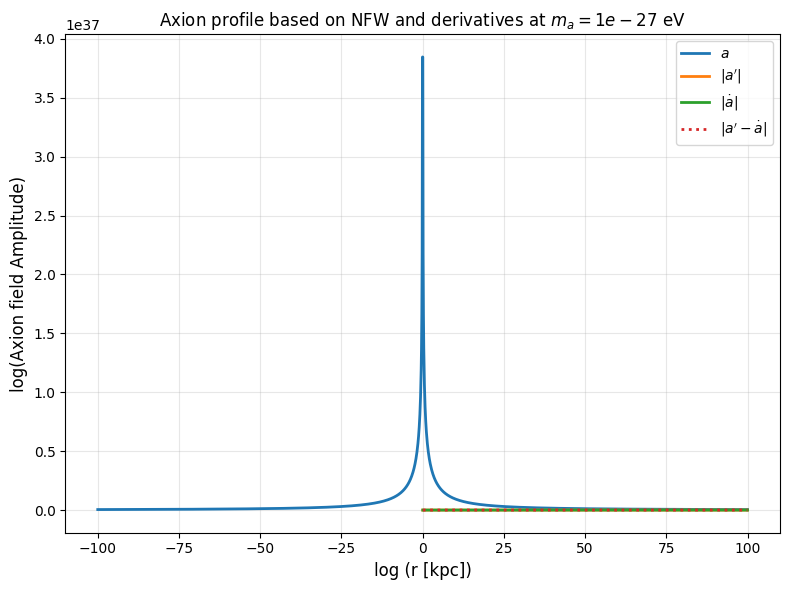

In [101]:
#derivatives of a , in static, i.e taking cos =1 , sin=1
# r_linear = np.linspace(-100.0, 100.0, 2000)
# r_normal = r_linear
# r = r_linear
#  gNFW Profile
x = r / r_s


# end-to-end 
def full_gnfw(r, M_0, r_s):
  
    r_magnitude = np.abs(r)
    return gnfw(r_magnitude, M_0, r_s)
def a_dot(r):
    return ( -1* np.sqrt(2 * rho_0) * (x)**-0.5 * (1 +x)**-1  )

def a_prime(r):
    return ( ( np.sqrt(2 * rho_0) / ( m_a * Rs) ) * ((-0.5 * (x)**-1.5 * (1 + x)**-1) + (-1* (x)**-0.5 * (1 + x)**-2)))

plt.figure(figsize=(8, 6))

plt.plot(r_linear ,a(r_linear),lw=2,label=r'$a$')

plt.plot(r_linear ,np.abs(a_prime(r_linear)),'-',lw=2,label=r'$|a^\prime|$')

plt.plot(r_linear ,np.abs(a_dot(r_linear)),'-',lw=2,label=r'$|\dot a|$')

plt.plot(r_linear ,np.abs(a_prime(r_linear) - a_dot(r_linear)),':',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field Amplitude)', fontsize=12)

plt.title(f"Axion profile based on NFW and derivatives at $m_a={m_a:.0e}$ eV")

plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()